In [1]:
# Cell 1: Environment Locking & Isolation (Manifesto Rule 4.1)
import sys
from pathlib import Path

expected_env_name = "scotland-ai-split-zones"
actual_path = Path(sys.executable)

assert expected_env_name in str(actual_path), (
    f"Kernel mismatch. Expected environment containing '{expected_env_name}', "
    f"but running in {actual_path}. Run `uv run jupyter lab` from the project root."
)
print(f"Environment verified: {actual_path}")

Environment verified: /home/ndrew/scotland-ai-split-zones/.venv/bin/python3


In [2]:
# Cell 2: Imports and Config Loading
import polars as pl
import yaml
import matplotlib.pyplot as plt
from pathlib import Path

ROOT_DIR = Path.cwd().parent
CONFIG_DIR = ROOT_DIR / "configs"
DATA_INTERMEDIATE = ROOT_DIR / "data" / "intermediate"
FIGURES_DIR = ROOT_DIR / "figures"

# Ensure output directories exist
DATA_INTERMEDIATE.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load workload flexibility assumptions (Manifesto Rule: Configuration, Not Magic Numbers)
with open(CONFIG_DIR / "workload_flexibility_assumptions.yml", "r") as f:
    workload_config = yaml.safe_load(f)

In [3]:
# Cell 3: Parquet Handoff (Manifesto Rule 4.2)
# Read the validated site register from Notebook 01. Do not pass dataframes in memory across notebooks.

parquet_path = DATA_INTERMEDIATE / "candidate_site_register.parquet"

if not parquet_path.exists():
    raise FileNotFoundError(
        f"Parquet handoff failed: {parquet_path} not found. "
        "Please run Notebook 01 to completion to generate the empirical site register."
    )

site_register = pl.read_parquet(parquet_path)
print(f"Loaded {len(site_register)} sites from intermediate parquet.")
print(f"Total empirical capacity: {site_register['capacity_mw'].sum():.2f} MW")

Loaded 7 sites from intermediate parquet.
Total empirical capacity: 2460.80 MW


In [4]:
# Cell 4: Response Curve Logic
# Manifesto Rule: Small Functions, Clear Contracts. No hidden global state.

def calculate_duration_compatibility(event_duration_h: float, notice_h: float, method: str = "soft_ratio") -> float:
    """
    Calculates duration compatibility factor.
    Soft ratio: min(1, event_duration / notice)
    Hard gate: 1 if event_duration >= notice else 0
    """
    if method == "soft_ratio":
        return min(1.0, event_duration_h / notice_h)
    elif method == "hard_gate":
        return 1.0 if event_duration_h >= notice_h else 0.0
    else:
        raise ValueError(f"Unknown method: {method}")

def estimate_flexible_response_mw(
    total_load_mw: float,
    schedulable_fraction: float,
    event_response_availability: float,
    duration_compatibility: float
) -> float:
    """
    Flexible Load Response MW = Total Load MW × Schedulable Fraction × Event Response Availability × Duration Compatibility
    """
    return total_load_mw * schedulable_fraction * event_response_availability * duration_compatibility

In [5]:
# Cell 5: Generate Sensitivity Matrix
# Manifesto Rule: Deterministic Baseline Before Randomness. We build an auditable grid of scenarios.

training_assumptions = workload_config["training_jobs"]
duration_method = workload_config["duration_compatibility"]["method"]

# Define sensitivity ranges directly from config (No magic numbers)
notice_periods_h = training_assumptions["notice_required_hours"] # e.g., [4, 12, 24]
schedulable_fractions = training_assumptions["schedulable_fraction"] # e.g., [0.1, 0.3, 0.5]
event_durations_h = [2, 4, 8, 12] # Representative grid constraint event durations

# Build a Cartesian product sensitivity matrix
sensitivity_data = []

for notice in notice_periods_h:
    for sched_frac in schedulable_fractions:
        for event_dur in event_durations_h:
            compat = calculate_duration_compatibility(event_dur, notice, method=duration_method)
            
            # Assume a baseline 100 MW compute load and 100% event response availability for the curve
            response_mw = estimate_flexible_response_mw(
                total_load_mw=100.0,
                schedulable_fraction=sched_frac,
                event_response_availability=1.0,
                duration_compatibility=compat
            )
            sensitivity_data.append({
                "notice_period_h": notice,
                "schedulable_fraction": sched_frac,
                "event_duration_h": event_dur,
                "duration_compatibility_factor": round(compat, 3),
                "flexible_response_mw": round(response_mw, 2)
            })

sensitivity_df = pl.DataFrame(sensitivity_data)
print("Sensitivity matrix generated:")
print(sensitivity_df)

Sensitivity matrix generated:
shape: (48, 5)
┌─────────────────┬────────────────────┬──────────────────┬────────────────────┬───────────────────┐
│ notice_period_h ┆ schedulable_fracti ┆ event_duration_h ┆ duration_compatibi ┆ flexible_response │
│ ---             ┆ on                 ┆ ---              ┆ lity_factor        ┆ _mw               │
│ i64             ┆ ---                ┆ i64              ┆ ---                ┆ ---               │
│                 ┆ f64                ┆                  ┆ f64                ┆ f64               │
╞═════════════════╪════════════════════╪══════════════════╪════════════════════╪═══════════════════╡
│ 4               ┆ 0.0                ┆ 2                ┆ 0.5                ┆ 0.0               │
│ 4               ┆ 0.0                ┆ 4                ┆ 1.0                ┆ 0.0               │
│ 4               ┆ 0.0                ┆ 8                ┆ 1.0                ┆ 0.0               │
│ 4               ┆ 0.0                ┆ 12   

In [6]:
# Cell 6: Save intermediate output for Notebook 03/05
output_path = DATA_INTERMEDIATE / "workload_response_sensitivity.parquet"
sensitivity_df.write_parquet(output_path)
print(f"Saved sensitivity matrix to {output_path}")

Saved sensitivity matrix to /home/ndrew/scotland-ai-split-zones/data/intermediate/workload_response_sensitivity.parquet


Saved figure to /home/ndrew/scotland-ai-split-zones/figures/workload_response_by_notice_period.png


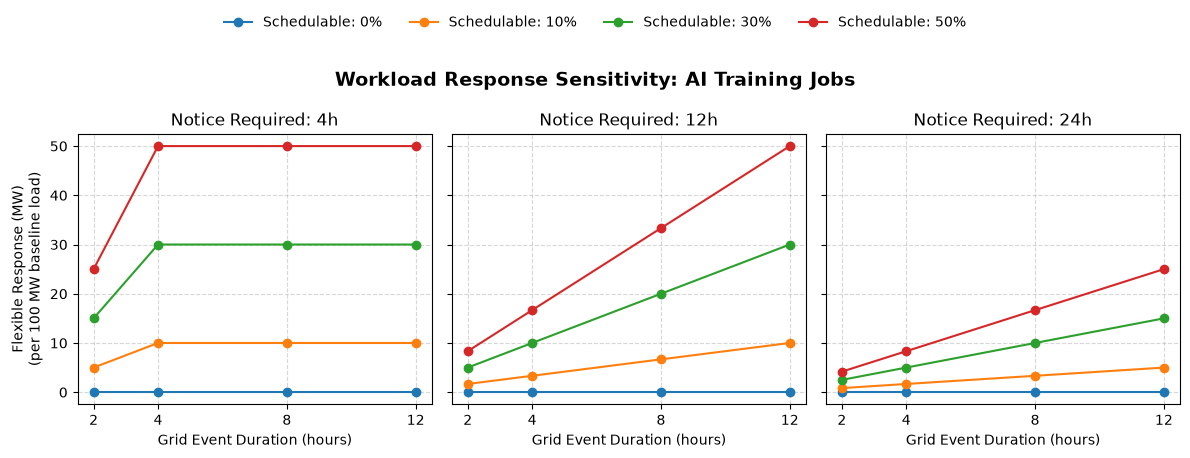

In [7]:
# Cell 7: Tufte-Compliant Visualization
# Manifesto Rule 9: Maximize data-ink ratio. Use small multiples. Show the denominator.

plt.style.use('default') # Clean slate, no chartjunk
fig, axes = plt.subplots(1, len(notice_periods_h), figsize=(12, 4), sharey=True)

for i, notice in enumerate(notice_periods_h):
    ax = axes[i]
    subset = sensitivity_df.filter(pl.col("notice_period_h") == notice)
    
    for sched_frac in schedulable_fractions:
        data = subset.filter(pl.col("schedulable_fraction") == sched_frac)
        ax.plot(
            data["event_duration_h"], 
            data["flexible_response_mw"], 
            marker='o', 
            label=f"Schedulable: {int(sched_frac*100)}%"
        )
    
    ax.set_title(f"Notice Required: {notice}h")
    ax.set_xlabel("Grid Event Duration (hours)")
    if i == 0:
        ax.set_ylabel("Flexible Response (MW)\n(per 100 MW baseline load)")
    
    # Minimal gridlines (Tufte standard)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks(event_durations_h)

# Legend outside the plot to avoid obscuring data
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=len(schedulable_fractions), frameon=False)

plt.suptitle("Workload Response Sensitivity: AI Training Jobs", fontsize=14, fontweight='bold')
plt.tight_layout()

# Save figure
fig_path = FIGURES_DIR / "workload_response_by_notice_period.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"Saved figure to {fig_path}")
plt.show()